In [ ]:
# Research Question:

# What factors can influence the Average Annual Daily Traffic (AADT) of a road segment in
# Loudoun County, Virginia?

# Factors to consider may include:
# 1. Higher k-factor increases overall higher AADT


In [1]:
import pandas as pd
import openpyxl

In [ ]:
# Load Excel data here, and drop unnamed columns
df = pd.read_excel('aadt_053_loudoun_2024.xlsx', engine='openpyxl')


unnamed_columns = [col for col in df.columns if 'Unnamed' in col]

df = df.drop(columns=unnamed_columns)

df.head()

,Link ID,RNS Route Name,Route Label,Route Alias,Physical Jurisdiction,Maintenance Jurisdiction,Start Label,End Label,Link Length,AADT,...,Percent Combination Trucks 1 Trailer,Percent Combination Trucks 2+ Trailer,Vehicle Classification Quality,K Factor,K Factor Quality,Direction Factor,AAWDT,AAWDT Quality,Data Date,Comment
0,190119,R-VA SR00007EB,VA 7 EB,Harry Flood Byrd Hwy,53.0,053,Clarke County Line,53-760 Near Bluemont,0.89,29000.0,...,0.01386,0.00001,F,0.0975,F,0.7758,32000.0,G,2024-01-01,NaN
1,090049,R-VA SR00007EB,VA 7 EB,Harry Flood Byrd Hwy,53.0,053,53-760 Near Bluemont,.31 mile E 53-1330,2.75,30000.0,...,0.01386,0.00001,C,0.1049,B,0.7457,NaN,NaN,2024-01-01,NaN
2,090049,R-VA SR00007EB,VA 7 EB,Harry Flood Byrd Hwy,53.0,053,.31 mile E 53-1330,Bus SR 7 West of Round Hill,0.27,30000.0,...,0.01386,0.00001,C,0.1049,B,0.7457,NaN,NaN,2024-01-01,NaN
3,190120,R-VA SR00007EB,VA 7 EB,Harry Flood Byrd Hwy,53.0,053,Bus SR 7 West of Round Hill,.47 mile E BUS VA 7,0.47,28000.0,...,0.01386,0.00001,F,0.0971,F,0.7728,31000.0,G,2024-01-01,NaN
4,190120,R-VA SR00007EB,VA 7 EB,Harry Flood Byrd Hwy,53.0,053,.47 mile E BUS VA 7,Bus SR 7 West of Purcellville,0.60,28000.0,...,0.01386,0.00001,F,0.0971,F,0.7728,31000.0,G,2024-01-01,NaN


In [ ]:
# drop columns with null AADT values
df = df.dropna(subset=['AADT', 'K Factor'])

len(df)


871

In [19]:
# Hypothesis:

"""As the k-factor increases, the AADT will also increase, due to the fact that a higher 
k-factor indicates a more commercial and central road, indicating a higher significance
and thereby higher traffic volume."""

'As the k-factor increases, the AADT will also increase, due to the fact that a higher \nk-factor indicates a more commercial and central road, indicating a higher significance\nand thereby higher traffic volume.'

In [48]:
data = df[['K Factor', 'AADT']]

data.head()

data.describe()
# Learned that k-factor could range from 0.074 to 0.313, with the mean being 0.111
# AADT could range from 40 to 158,000, with the mean being 12900

,K Factor,AADT
count,871.000000,871.000000
mean,0.110515,12900.315729
std,0.028405,21002.460787
min,0.073900,40.000000
25%,0.094100,2650.000000
50%,0.101800,6800.000000
75%,0.117350,13000.000000
max,0.312500,158000.000000


In [49]:
# get rid of outliers in AADT column, by getting rid of the bottom 3% and top 3% of AADT values
data = data[(data['AADT'] > data['AADT'].quantile(0.03)) & (data['AADT'] < data['AADT'].quantile(0.97))]
# get rid of outliers in K Factor column, by getting rid of the bottom 3% and top 3% of K Factor values
data = data[(data['K Factor'] > data['K Factor'].quantile(0.03)) & (data['K Factor'] < data['K Factor'].quantile(0.97))]
data.describe()

,K Factor,AADT
count,760.000000,760.000000
mean,0.108174,9119.144737
std,0.020278,9922.438349
min,0.080100,350.000000
25%,0.095575,2800.000000
50%,0.101800,6400.000000
75%,0.114000,12000.000000
max,0.174700,65000.000000


In [50]:
import sklearn
from sklearn.linear_model import LinearRegression

In [51]:
X = data[['K Factor']]
y = data['AADT']

model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [52]:
# print the R-squared value, mean squared error, and mean absolute error of the model
y_pred = model.predict(X)
print("R-squared:", r2_score(y, y_pred))
print("Mean Squared Error:", mean_squared_error(y, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y, y_pred))

R-squared: 0.12709178456828307
Mean Squared Error: 85828907.18922682
Mean Absolute Error: 6226.485029575414


In [45]:
import matplotlib.pyplot as plt

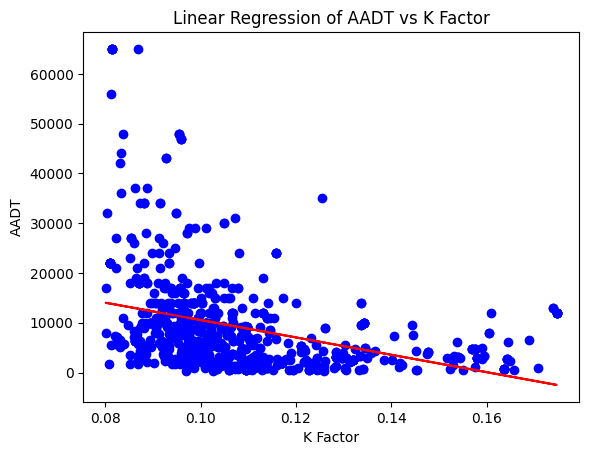

In [53]:
plt.scatter(X, y, color='blue')
plt.plot(X, model.predict(X), color='red')
plt.xlabel('K Factor')
plt.ylabel('AADT')
plt.title('Linear Regression of AADT vs K Factor')
plt.show()